In [1]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Is this notebook running on Colab or Kaggle?
IS_COLAB = "google.colab" in sys.modules
IS_KAGGLE = "kaggle_secrets" in sys.modules

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

# TensorFlow ≥2.0 is required
import tensorflow as tf
from tensorflow import keras
assert tf.__version__ >= "2.0"

if not tf.config.list_physical_devices('GPU'):
    print("No GPU was detected. LSTMs and CNNs can be very slow without a GPU.")
    if IS_COLAB:
        print("Go to Runtime > Change runtime and select a GPU hardware accelerator.")
    if IS_KAGGLE:
        print("Go to Settings > Accelerator and select GPU.")

# Common imports
import numpy as np
import os
from pathlib import Path

# to make this notebook's output stable across runs
np.random.seed(42)
tf.random.set_seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Where to save the figures
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "rnn"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

2025-07-08 19:01:39.338493: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-07-08 19:01:39.531065: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-08 19:01:40.293222: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory
2025-07-08 19:01:40.293395: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer_plugin.so.7'; dlerror: libnvinfer_plugin.so.7: cannot open shared object file: No such file or 

No GPU was detected. LSTMs and CNNs can be very slow without a GPU.


In [2]:
def generate_time_series(batch_size, n_steps):
    freq1, freq2, offsets1, offsets2 = np.random.rand(4, batch_size, 1)
    time = np.linspace(0, 1, n_steps)
    series = 0.5 * np.sin((time - offsets1) * (freq1 * 10 + 10))  #   wave 1
    series += 0.2 * np.sin((time - offsets2) * (freq2 * 20 + 20)) # + wave 2
    series += 0.1 * (np.random.rand(batch_size, n_steps) - 0.5)   # + noise
    return series[..., np.newaxis].astype(np.float32)

In [3]:
np.random.seed(42)

n_steps = 50
series = generate_time_series(10000, n_steps + 1)
X_train, y_train = series[:7000, :n_steps], series[:7000, -1]
X_valid, y_valid = series[7000:9000, :n_steps], series[7000:9000, -1]
X_test, y_test = series[9000:, :n_steps], series[9000:, -1]

In [4]:
X_train.shape, y_train.shape

((7000, 50, 1), (7000, 1))

Saving figure time_series_plot


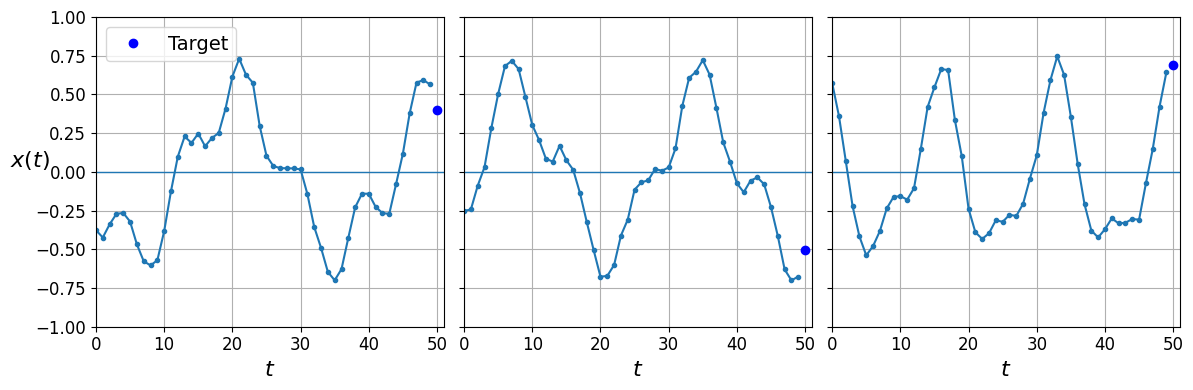

In [5]:
def plot_series(series, y=None, y_pred=None, x_label="$t$", y_label="$x(t)$", legend=True):
    plt.plot(series, ".-")
    if y is not None:
        plt.plot(n_steps, y, "bo", label="Target")
    if y_pred is not None:
        plt.plot(n_steps, y_pred, "rx", markersize=10, label="Prediction")
    plt.grid(True)
    if x_label:
        plt.xlabel(x_label, fontsize=16)
    if y_label:
        plt.ylabel(y_label, fontsize=16, rotation=0)
    plt.hlines(0, 0, 100, linewidth=1)
    plt.axis([0, n_steps + 1, -1, 1])
    if legend and (y or y_pred):
        plt.legend(fontsize=14, loc="upper left")

fig, axes = plt.subplots(nrows=1, ncols=3, sharey=True, figsize=(12, 4))
for col in range(3):
    plt.sca(axes[col])
    plot_series(X_valid[col, :, 0], y_valid[col, 0],
                y_label=("$x(t)$" if col==0 else None),
                legend=(col == 0))
save_fig("time_series_plot")
plt.show()

In [6]:
y_pred = X_valid[:, -1]
np.mean(keras.losses.mean_squared_error(y_valid, y_pred))


2025-07-08 19:01:42.862368: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


0.020211367

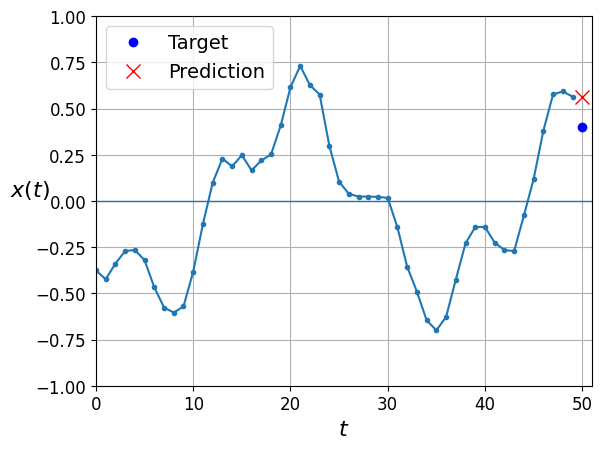

In [7]:

plot_series(X_valid[0, :, 0], y_valid[0, 0], y_pred[0, 0])
plt.show()

In [8]:
np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[50, 1]),
    keras.layers.Dense(1)
])

model.compile(loss="mse", optimizer="adam")
history = model.fit(X_train, y_train, epochs=20,
                    validation_data=(X_valid, y_valid))

Epoch 1/20
219/219 [==============================] - 1s 2ms/step - loss: 0.0915 - val_loss: 0.0317
Epoch 2/20
219/219 [==============================] - 0s 2ms/step - loss: 0.0221 - val_loss: 0.0160
Epoch 3/20
219/219 [==============================] - 0s 2ms/step - loss: 0.0134 - val_loss: 0.0117
Epoch 4/20
219/219 [==============================] - 0s 2ms/step - loss: 0.0104 - val_loss: 0.0098
Epoch 5/20
219/219 [==============================] - 0s 2ms/step - loss: 0.0089 - val_loss: 0.0086
Epoch 6/20
219/219 [==============================] - 0s 2ms/step - loss: 0.0078 - val_loss: 0.0077
Epoch 7/20
219/219 [==============================] - 0s 2ms/step - loss: 0.0070 - val_loss: 0.0069
Epoch 8/20
219/219 [==============================] - 0s 2ms/step - loss: 0.0063 - val_loss: 0.0062
Epoch 9/20
219/219 [==============================] - 0s 2ms/step - loss: 0.0058 - val_loss: 0.0057
Epoch 10/20
219/219 [==============================] - 0s 2ms/step - loss: 0.0054 - val_loss: 0.0054

In [9]:
model.evaluate(X_valid, y_valid)

63/63 [==============================] - 0s 2ms/step - loss: 0.0037


0.003718996187672019

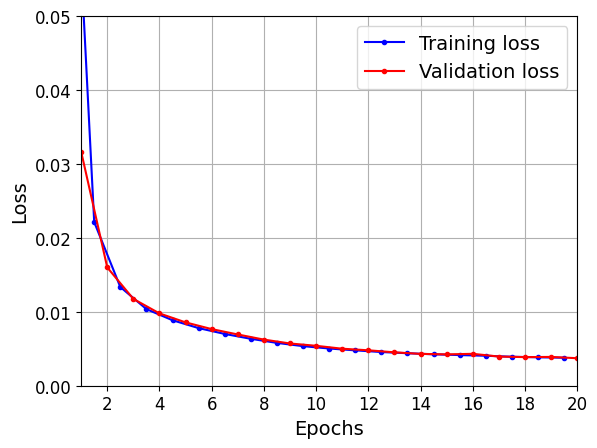

In [10]:
def plot_learning_curves(loss, val_loss):
    plt.plot(np.arange(len(loss)) + 0.5, loss, "b.-", label="Training loss")
    plt.plot(np.arange(len(val_loss)) + 1, val_loss, "r.-", label="Validation loss")
    plt.gca().xaxis.set_major_locator(mpl.ticker.MaxNLocator(integer=True))
    plt.axis([1, 20, 0, 0.05])
    plt.legend(fontsize=14)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.grid(True)

plot_learning_curves(history.history["loss"], history.history["val_loss"])
plt.show()

63/63 [==============================] - 0s 1ms/step


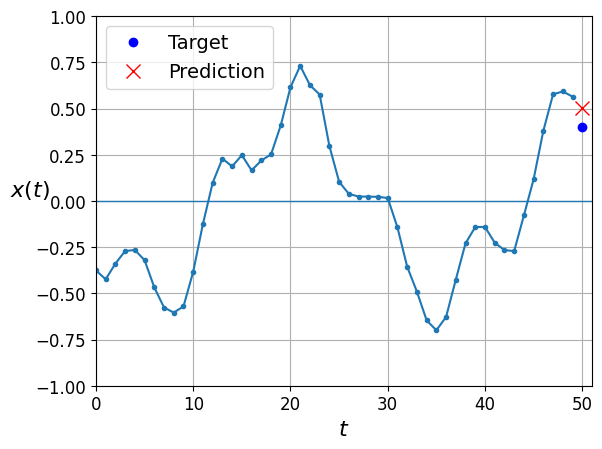

In [11]:
y_pred = model.predict(X_valid)
plot_series(X_valid[0, :, 0], y_valid[0, 0], y_pred[0, 0])
plt.show()

In [12]:
np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.SimpleRNN(1, input_shape=[None, 1])
])

optimizer = keras.optimizers.Adam(learning_rate=0.005)
model.compile(loss="mse", optimizer=optimizer)
history = model.fit(X_train, y_train, epochs=20,
                    validation_data=(X_valid, y_valid))

Epoch 1/20
219/219 [==============================] - 3s 11ms/step - loss: 0.1183 - val_loss: 0.0361
Epoch 2/20
219/219 [==============================] - 4s 19ms/step - loss: 0.0299 - val_loss: 0.0253
Epoch 3/20
219/219 [==============================] - 4s 19ms/step - loss: 0.0223 - val_loss: 0.0196
Epoch 4/20
219/219 [==============================] - 4s 20ms/step - loss: 0.0181 - val_loss: 0.0163
Epoch 5/20
219/219 [==============================] - 4s 19ms/step - loss: 0.0155 - val_loss: 0.0142
Epoch 6/20
219/219 [==============================] - 4s 19ms/step - loss: 0.0138 - val_loss: 0.0128
Epoch 7/20
219/219 [==============================] - 4s 18ms/step - loss: 0.0127 - val_loss: 0.0119
Epoch 8/20
219/219 [==============================] - 4s 18ms/step - loss: 0.0120 - val_loss: 0.0114
Epoch 9/20
219/219 [==============================] - 3s 13ms/step - loss: 0.0116 - val_loss: 0.0111
Epoch 10/20
219/219 [==============================] - 5s 21ms/step - loss: 0.0115 - val_lo

In [13]:
model.evaluate(X_valid, y_valid)

63/63 [==============================] - 0s 7ms/step - loss: 0.0109


0.010884602554142475

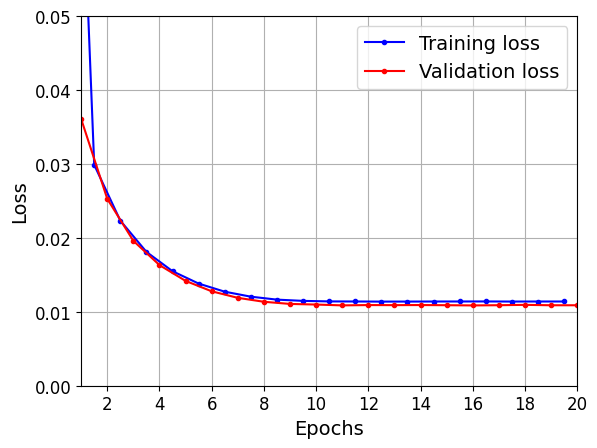

In [14]:
plot_learning_curves(history.history["loss"], history.history["val_loss"])
plt.show()

63/63 [==============================] - 1s 8ms/step


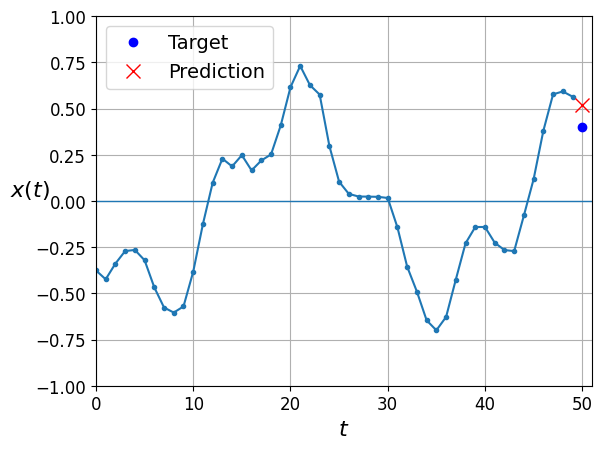

In [15]:
y_pred = model.predict(X_valid)
plot_series(X_valid[0, :, 0], y_valid[0, 0], y_pred[0, 0])
plt.show()

In [16]:
np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[None, 1]),
    keras.layers.SimpleRNN(20, return_sequences=True),
    keras.layers.SimpleRNN(1)
])

model.compile(loss="mse", optimizer="adam")
history = model.fit(X_train, y_train, epochs=20,
                    validation_data=(X_valid, y_valid))

Epoch 1/20
219/219 [==============================] - 16s 62ms/step - loss: 0.0372 - val_loss: 0.0085
Epoch 2/20
219/219 [==============================] - 15s 67ms/step - loss: 0.0059 - val_loss: 0.0059
Epoch 3/20
219/219 [==============================] - 13s 60ms/step - loss: 0.0048 - val_loss: 0.0039
Epoch 4/20
219/219 [==============================] - 17s 79ms/step - loss: 0.0042 - val_loss: 0.0035
Epoch 5/20
219/219 [==============================] - 14s 62ms/step - loss: 0.0042 - val_loss: 0.0044
Epoch 6/20
219/219 [==============================] - 17s 78ms/step - loss: 0.0039 - val_loss: 0.0033
Epoch 7/20
219/219 [==============================] - 14s 63ms/step - loss: 0.0038 - val_loss: 0.0042
Epoch 8/20
219/219 [==============================] - 15s 67ms/step - loss: 0.0037 - val_loss: 0.0032
Epoch 9/20
219/219 [==============================] - 13s 61ms/step - loss: 0.0036 - val_loss: 0.0036
Epoch 10/20
219/219 [==============================] - 15s 68ms/step - loss: 0.003

In [17]:
model.evaluate(X_valid, y_valid)

63/63 [==============================] - 1s 22ms/step - loss: 0.0030


0.002960535464808345

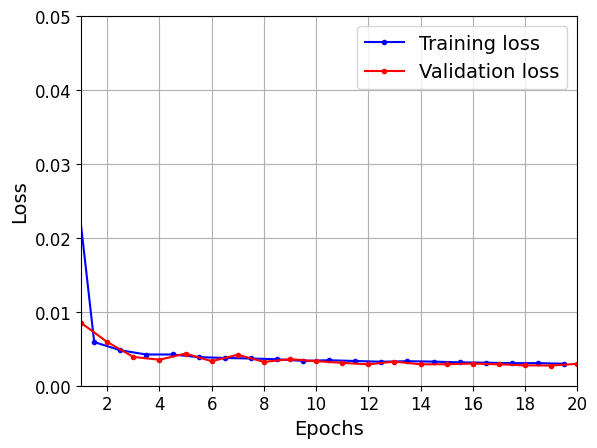

In [18]:
plot_learning_curves(history.history["loss"], history.history["val_loss"])
plt.show()

63/63 [==============================] - 2s 19ms/step


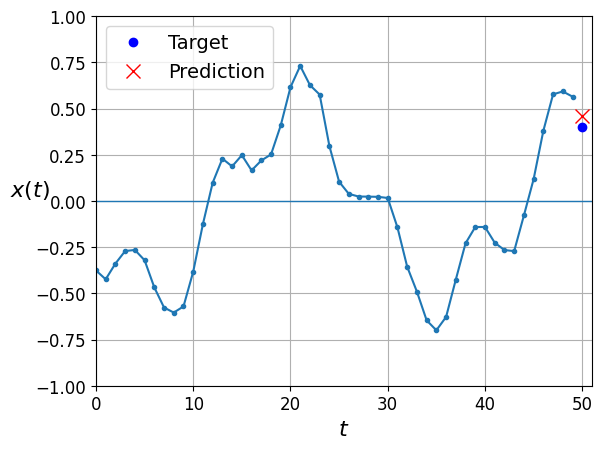

In [19]:
y_pred = model.predict(X_valid)
plot_series(X_valid[0, :, 0], y_valid[0, 0], y_pred[0, 0])
plt.show()

In [20]:
np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[None, 1]),
    keras.layers.SimpleRNN(20),
    keras.layers.Dense(1)
])

model.compile(loss="mse", optimizer="adam")
history = model.fit(X_train, y_train, epochs=20,
                    validation_data=(X_valid, y_valid))

Epoch 1/20
219/219 [==============================] - 12s 47ms/step - loss: 0.0212 - val_loss: 0.0056
Epoch 2/20
219/219 [==============================] - 10s 46ms/step - loss: 0.0043 - val_loss: 0.0038
Epoch 3/20
219/219 [==============================] - 8s 36ms/step - loss: 0.0034 - val_loss: 0.0030
Epoch 4/20
219/219 [==============================] - 10s 47ms/step - loss: 0.0032 - val_loss: 0.0029
Epoch 5/20
219/219 [==============================] - 10s 44ms/step - loss: 0.0031 - val_loss: 0.0029
Epoch 6/20
219/219 [==============================] - 8s 36ms/step - loss: 0.0030 - val_loss: 0.0027
Epoch 7/20
219/219 [==============================] - 10s 47ms/step - loss: 0.0029 - val_loss: 0.0029
Epoch 8/20
219/219 [==============================] - 10s 45ms/step - loss: 0.0030 - val_loss: 0.0028
Epoch 9/20
219/219 [==============================] - 9s 41ms/step - loss: 0.0030 - val_loss: 0.0027
Epoch 10/20
219/219 [==============================] - 10s 47ms/step - loss: 0.0028 -

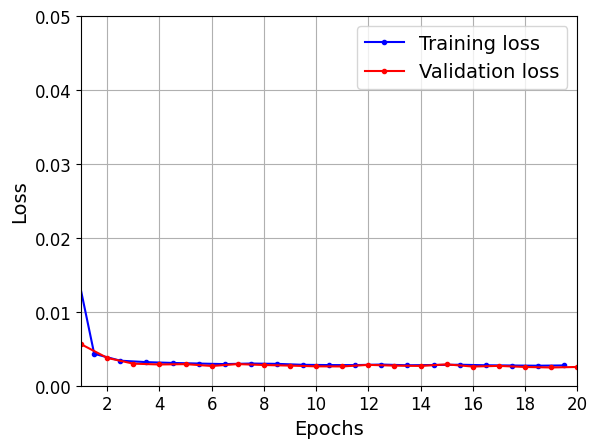

In [21]:
plot_learning_curves(history.history["loss"], history.history["val_loss"])
plt.show()

63/63 [==============================] - 1s 12ms/step


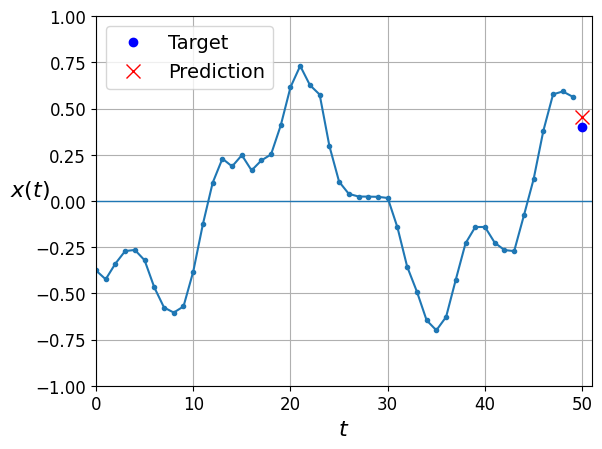

In [22]:
y_pred = model.predict(X_valid)
plot_series(X_valid[0, :, 0], y_valid[0, 0], y_pred[0, 0])
plt.show()

In [23]:
np.random.seed(43) # not 42, as it would give the first series in the train set

series = generate_time_series(1, n_steps + 10)
X_new, Y_new = series[:, :n_steps], series[:, n_steps:]
X = X_new
for step_ahead in range(10):
    y_pred_one = model.predict(X[:, step_ahead:])[:, np.newaxis, :]
    X = np.concatenate([X, y_pred_one], axis=1)

Y_pred = X[:, n_steps:]

1/1 [==============================] - 0s 33ms/step


In [24]:
Y_pred.shape

(1, 10, 1)

Saving figure forecast_ahead_plot


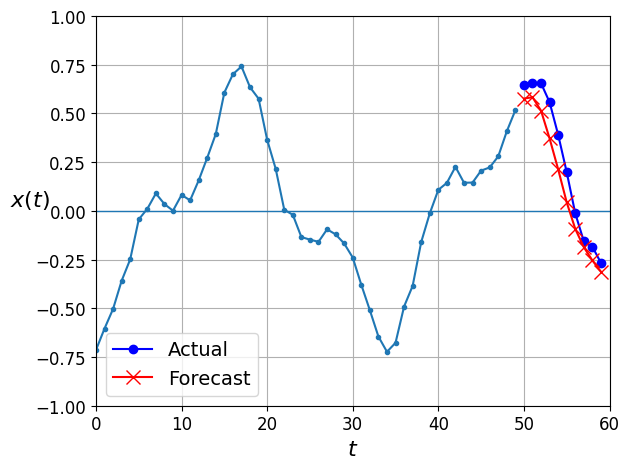

In [25]:
def plot_multiple_forecasts(X, Y, Y_pred):
    n_steps = X.shape[1]
    ahead = Y.shape[1]
    plot_series(X[0, :, 0])
    plt.plot(np.arange(n_steps, n_steps + ahead), Y[0, :, 0], "bo-", label="Actual")
    plt.plot(np.arange(n_steps, n_steps + ahead), Y_pred[0, :, 0], "rx-", label="Forecast", markersize=10)
    plt.axis([0, n_steps + ahead, -1, 1])
    plt.legend(fontsize=14)

plot_multiple_forecasts(X_new, Y_new, Y_pred)
save_fig("forecast_ahead_plot")
plt.show()

In [26]:
np.random.seed(42)

n_steps = 50
series = generate_time_series(10000, n_steps + 10)
X_train, Y_train = series[:7000, :n_steps], series[:7000, -10:, 0]
X_valid, Y_valid = series[7000:9000, :n_steps], series[7000:9000, -10:, 0]
X_test, Y_test = series[9000:, :n_steps], series[9000:, -10:, 0]

In [27]:
X = X_valid
for step_ahead in range(10):
    y_pred_one = model.predict(X)[:, np.newaxis, :]
    X = np.concatenate([X, y_pred_one], axis=1)

Y_pred = X[:, n_steps:, 0]

63/63 [==============================] - 1s 14ms/step


In [28]:
Y_pred.shape

(2000, 10)

In [29]:
np.mean(keras.metrics.mean_squared_error(Y_valid, Y_pred))

0.020474197

In [30]:
Y_naive_pred = np.tile(X_valid[:, -1], 10) # take the last time step value, and repeat it 10 times
np.mean(keras.metrics.mean_squared_error(Y_valid, Y_naive_pred))

0.25697407

In [31]:
np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[50, 1]),
    keras.layers.Dense(10)
])

model.compile(loss="mse", optimizer="adam")
history = model.fit(X_train, Y_train, epochs=20,
                    validation_data=(X_valid, Y_valid))

Epoch 1/20
219/219 [==============================] - 1s 3ms/step - loss: 0.1719 - val_loss: 0.0741
Epoch 2/20
219/219 [==============================] - 1s 2ms/step - loss: 0.0586 - val_loss: 0.0476
Epoch 3/20
219/219 [==============================] - 1s 2ms/step - loss: 0.0421 - val_loss: 0.0375
Epoch 4/20
219/219 [==============================] - 1s 2ms/step - loss: 0.0351 - val_loss: 0.0325
Epoch 5/20
219/219 [==============================] - 1s 2ms/step - loss: 0.0311 - val_loss: 0.0294
Epoch 6/20
219/219 [==============================] - 1s 2ms/step - loss: 0.0284 - val_loss: 0.0273
Epoch 7/20
219/219 [==============================] - 1s 2ms/step - loss: 0.0264 - val_loss: 0.0256
Epoch 8/20
219/219 [==============================] - 1s 2ms/step - loss: 0.0250 - val_loss: 0.0243
Epoch 9/20
219/219 [==============================] - 1s 2ms/step - loss: 0.0239 - val_loss: 0.0233
Epoch 10/20
219/219 [==============================] - 1s 3ms/step - loss: 0.0230 - val_loss: 0.0225

In [32]:
np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[None, 1]),
    keras.layers.SimpleRNN(20),
    keras.layers.Dense(10)
])

model.compile(loss="mse", optimizer="adam")
history = model.fit(X_train, Y_train, epochs=20,
                    validation_data=(X_valid, Y_valid))

Epoch 1/20
219/219 [==============================] - 11s 45ms/step - loss: 0.0532 - val_loss: 0.0267
Epoch 2/20
219/219 [==============================] - 8s 35ms/step - loss: 0.0242 - val_loss: 0.0186
Epoch 3/20
219/219 [==============================] - 9s 42ms/step - loss: 0.0171 - val_loss: 0.0138
Epoch 4/20
219/219 [==============================] - 9s 42ms/step - loss: 0.0142 - val_loss: 0.0123
Epoch 5/20
219/219 [==============================] - 9s 42ms/step - loss: 0.0125 - val_loss: 0.0118
Epoch 6/20
219/219 [==============================] - 8s 35ms/step - loss: 0.0120 - val_loss: 0.0102
Epoch 7/20
219/219 [==============================] - 10s 47ms/step - loss: 0.0113 - val_loss: 0.0106
Epoch 8/20
219/219 [==============================] - 10s 45ms/step - loss: 0.0109 - val_loss: 0.0093
Epoch 9/20
219/219 [==============================] - 8s 35ms/step - loss: 0.0106 - val_loss: 0.0115
Epoch 10/20
219/219 [==============================] - 9s 42ms/step - loss: 0.0104 - val

In [34]:
np.random.seed(43)

series = generate_time_series(1, 50 + 10)
X_new, Y_new = series[:, :50, :], series[:, -10:, :]
Y_pred = model.predict(X_new)[..., np.newaxis]

1/1 [==============================] - 0s 251ms/step


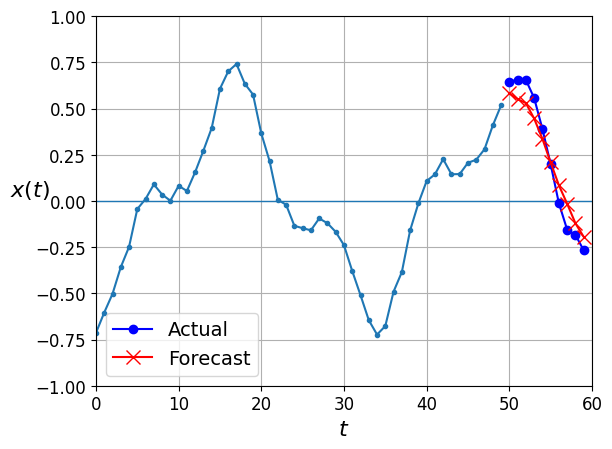

In [35]:
plot_multiple_forecasts(X_new, Y_new, Y_pred)
plt.show()

In [36]:
np.random.seed(42)

n_steps = 50
series = generate_time_series(10000, n_steps + 10)
X_train = series[:7000, :n_steps]
X_valid = series[7000:9000, :n_steps]
X_test = series[9000:, :n_steps]
Y = np.empty((10000, n_steps, 10))
for step_ahead in range(1, 10 + 1):
    Y[..., step_ahead - 1] = series[..., step_ahead:step_ahead + n_steps, 0]
Y_train = Y[:7000]
Y_valid = Y[7000:9000]
Y_test = Y[9000:]

In [37]:
X_train.shape, Y_train.shape

((7000, 50, 1), (7000, 50, 10))

In [38]:
np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[None, 1]),
    keras.layers.SimpleRNN(20, return_sequences=True),
    keras.layers.TimeDistributed(keras.layers.Dense(10))
])

def last_time_step_mse(Y_true, Y_pred):
    return keras.metrics.mean_squared_error(Y_true[:, -1], Y_pred[:, -1])

model.compile(loss="mse", optimizer=keras.optimizers.Adam(learning_rate=0.01), metrics=[last_time_step_mse])
history = model.fit(X_train, Y_train, epochs=20,
                    validation_data=(X_valid, Y_valid))

Epoch 1/20
219/219 [==============================] - 11s 44ms/step - loss: 0.0478 - last_time_step_mse: 0.0375 - val_loss: 0.0425 - val_last_time_step_mse: 0.0321
Epoch 2/20
219/219 [==============================] - 8s 36ms/step - loss: 0.0395 - last_time_step_mse: 0.0288 - val_loss: 0.0321 - val_last_time_step_mse: 0.0199
Epoch 3/20
219/219 [==============================] - 9s 42ms/step - loss: 0.0327 - last_time_step_mse: 0.0219 - val_loss: 0.0313 - val_last_time_step_mse: 0.0227
Epoch 4/20
219/219 [==============================] - 9s 41ms/step - loss: 0.0289 - last_time_step_mse: 0.0174 - val_loss: 0.0258 - val_last_time_step_mse: 0.0145
Epoch 5/20
219/219 [==============================] - 8s 34ms/step - loss: 0.0261 - last_time_step_mse: 0.0142 - val_loss: 0.0249 - val_last_time_step_mse: 0.0137
Epoch 6/20
219/219 [==============================] - 9s 41ms/step - loss: 0.0249 - last_time_step_mse: 0.0127 - val_loss: 0.0220 - val_last_time_step_mse: 0.0094
Epoch 7/20
219/219 [=

In [39]:
np.random.seed(43)

series = generate_time_series(1, 50 + 10)
X_new, Y_new = series[:, :50, :], series[:, 50:, :]
Y_pred = model.predict(X_new)[:, -1][..., np.newaxis]

1/1 [==============================] - 0s 266ms/step


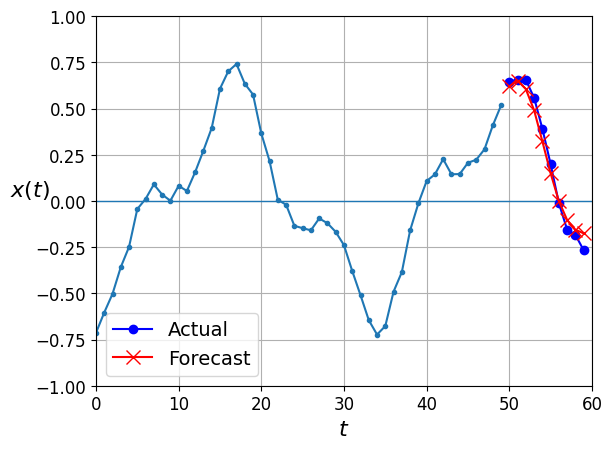

In [40]:
plot_multiple_forecasts(X_new, Y_new, Y_pred)
plt.show()

In [41]:
np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[None, 1]),
    keras.layers.BatchNormalization(),
    keras.layers.SimpleRNN(20, return_sequences=True),
    keras.layers.BatchNormalization(),
    keras.layers.TimeDistributed(keras.layers.Dense(10))
])

model.compile(loss="mse", optimizer="adam", metrics=[last_time_step_mse])
history = model.fit(X_train, Y_train, epochs=20,
                    validation_data=(X_valid, Y_valid))

Epoch 1/20
219/219 [==============================] - 11s 45ms/step - loss: 0.1217 - last_time_step_mse: 0.1073 - val_loss: 0.0751 - val_last_time_step_mse: 0.0672
Epoch 2/20
219/219 [==============================] - 8s 37ms/step - loss: 0.0494 - last_time_step_mse: 0.0388 - val_loss: 0.0499 - val_last_time_step_mse: 0.0402
Epoch 3/20
219/219 [==============================] - 10s 44ms/step - loss: 0.0436 - last_time_step_mse: 0.0329 - val_loss: 0.0421 - val_last_time_step_mse: 0.0317
Epoch 4/20
219/219 [==============================] - 10s 44ms/step - loss: 0.0409 - last_time_step_mse: 0.0303 - val_loss: 0.0398 - val_last_time_step_mse: 0.0291
Epoch 5/20
219/219 [==============================] - 8s 36ms/step - loss: 0.0395 - last_time_step_mse: 0.0291 - val_loss: 0.0389 - val_last_time_step_mse: 0.0283
Epoch 6/20
219/219 [==============================] - 10s 44ms/step - loss: 0.0382 - last_time_step_mse: 0.0276 - val_loss: 0.0375 - val_last_time_step_mse: 0.0270
Epoch 7/20
219/219

In [42]:
class MyRNN(keras.layers.Layer):
    def __init__(self, cell, return_sequences=False, **kwargs):
        super().__init__(**kwargs)
        self.cell = cell
        self.return_sequences = return_sequences
        self.get_initial_state = getattr(
            self.cell, "get_initial_state", self.fallback_initial_state)
    def fallback_initial_state(self, inputs):
        batch_size = tf.shape(inputs)[0]
        return [tf.zeros([batch_size, self.cell.state_size], dtype=inputs.dtype)]
    @tf.function
    def call(self, inputs):
        states = self.get_initial_state(inputs)
        shape = tf.shape(inputs)
        batch_size = shape[0]
        n_steps = shape[1]
        sequences = tf.TensorArray(
            inputs.dtype, size=(n_steps if self.return_sequences else 0))
        outputs = tf.zeros(shape=[batch_size, self.cell.output_size], dtype=inputs.dtype)
        for step in tf.range(n_steps):
            outputs, states = self.cell(inputs[:, step], states)
            if self.return_sequences:
                sequences = sequences.write(step, outputs)
        if self.return_sequences:
            return tf.transpose(sequences.stack(), [1, 0, 2])
        else:
            return outputs

In [50]:
np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    MyRNN(LNSimpleRNNCell(20), return_sequences=True,
          input_shape=[None, 1]),
    MyRNN(LNSimpleRNNCell(20), return_sequences=True),
    keras.layers.TimeDistributed(keras.layers.Dense(10))
])

model.compile(loss="mse", optimizer="adam", metrics=[last_time_step_mse])
history = model.fit(X_train, Y_train, epochs=20,
                    validation_data=(X_valid, Y_valid))

Epoch 1/20
219/219 [==============================] - 20s 82ms/step - loss: 0.1494 - last_time_step_mse: 0.1241 - val_loss: 0.0610 - val_last_time_step_mse: 0.0495
Epoch 2/20
219/219 [==============================] - 20s 90ms/step - loss: 0.0547 - last_time_step_mse: 0.0427 - val_loss: 0.0503 - val_last_time_step_mse: 0.0389
Epoch 3/20
219/219 [==============================] - 21s 94ms/step - loss: 0.0482 - last_time_step_mse: 0.0365 - val_loss: 0.0455 - val_last_time_step_mse: 0.0344
Epoch 4/20
219/219 [==============================] - 20s 92ms/step - loss: 0.0438 - last_time_step_mse: 0.0319 - val_loss: 0.0414 - val_last_time_step_mse: 0.0303
Epoch 5/20
219/219 [==============================] - 20s 93ms/step - loss: 0.0393 - last_time_step_mse: 0.0266 - val_loss: 0.0368 - val_last_time_step_mse: 0.0241
Epoch 6/20
219/219 [==============================] - 22s 99ms/step - loss: 0.0361 - last_time_step_mse: 0.0227 - val_loss: 0.0340 - val_last_time_step_mse: 0.0208
Epoch 7/20
219/2

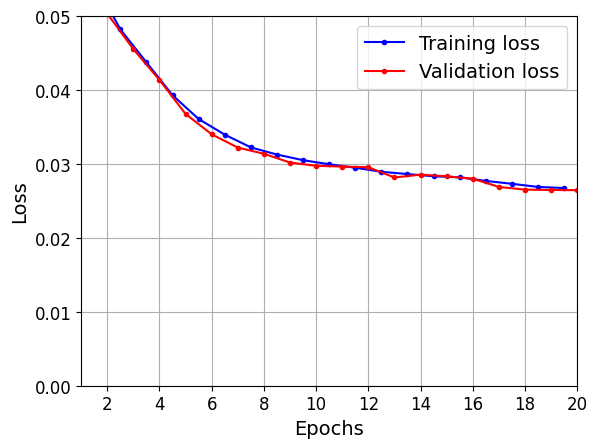

In [53]:
plot_learning_curves(history.history["loss"], history.history["val_loss"])
plt.show()

In [54]:

np.random.seed(43)

series = generate_time_series(1, 50 + 10)
X_new, Y_new = series[:, :50, :], series[:, 50:, :]
Y_pred = model.predict(X_new)[:, -1][..., np.newaxis]

1/1 [==============================] - 0s 201ms/step


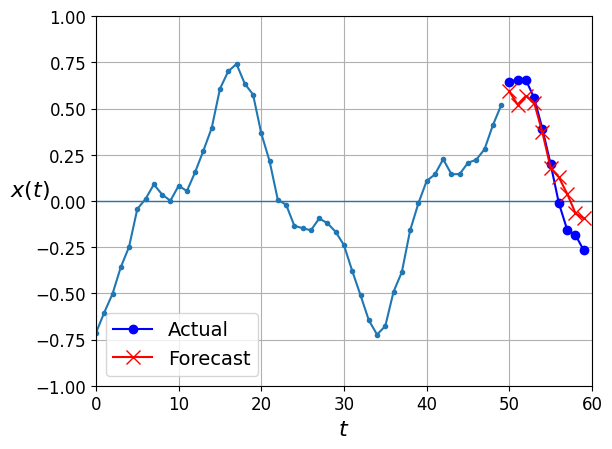

In [55]:
plot_multiple_forecasts(X_new, Y_new, Y_pred)
plt.show()


In [56]:
np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.GRU(20, return_sequences=True, input_shape=[None, 1]),
    keras.layers.GRU(20, return_sequences=True),
    keras.layers.TimeDistributed(keras.layers.Dense(10))
])

model.compile(loss="mse", optimizer="adam", metrics=[last_time_step_mse])
history = model.fit(X_train, Y_train, epochs=20,
                    validation_data=(X_valid, Y_valid))

Epoch 1/20
219/219 [==============================] - 23s 89ms/step - loss: 0.0777 - last_time_step_mse: 0.0697 - val_loss: 0.0532 - val_last_time_step_mse: 0.0427
Epoch 2/20
219/219 [==============================] - 18s 84ms/step - loss: 0.0486 - last_time_step_mse: 0.0380 - val_loss: 0.0454 - val_last_time_step_mse: 0.0341
Epoch 3/20
219/219 [==============================] - 20s 91ms/step - loss: 0.0439 - last_time_step_mse: 0.0327 - val_loss: 0.0420 - val_last_time_step_mse: 0.0305
Epoch 4/20
219/219 [==============================] - 19s 86ms/step - loss: 0.0407 - last_time_step_mse: 0.0296 - val_loss: 0.0386 - val_last_time_step_mse: 0.0268
Epoch 5/20
219/219 [==============================] - 21s 94ms/step - loss: 0.0370 - last_time_step_mse: 0.0258 - val_loss: 0.0348 - val_last_time_step_mse: 0.0231
Epoch 6/20
219/219 [==============================] - 23s 107ms/step - loss: 0.0329 - last_time_step_mse: 0.0204 - val_loss: 0.0309 - val_last_time_step_mse: 0.0176
Epoch 7/20
219/

In [57]:
model.evaluate(X_valid, Y_valid)

63/63 [==============================] - 1s 19ms/step - loss: 0.0236 - last_time_step_mse: 0.0100


[0.023613538593053818, 0.009986882098019123]

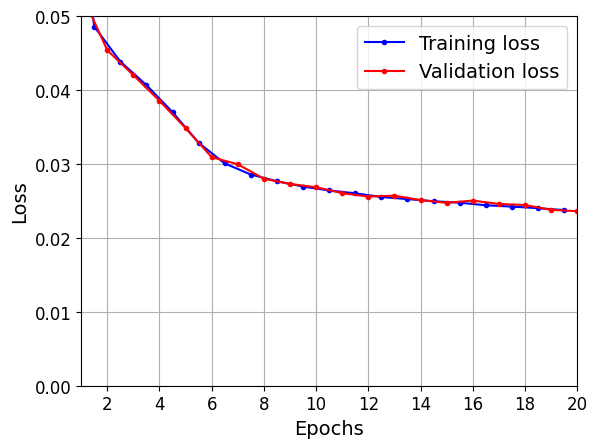

In [58]:
plot_learning_curves(history.history["loss"], history.history["val_loss"])
plt.show()

In [59]:
np.random.seed(43)

series = generate_time_series(1, 50 + 10)
X_new, Y_new = series[:, :50, :], series[:, 50:, :]
Y_pred = model.predict(X_new)[:, -1][..., np.newaxis]

1/1 [==============================] - 1s 696ms/step


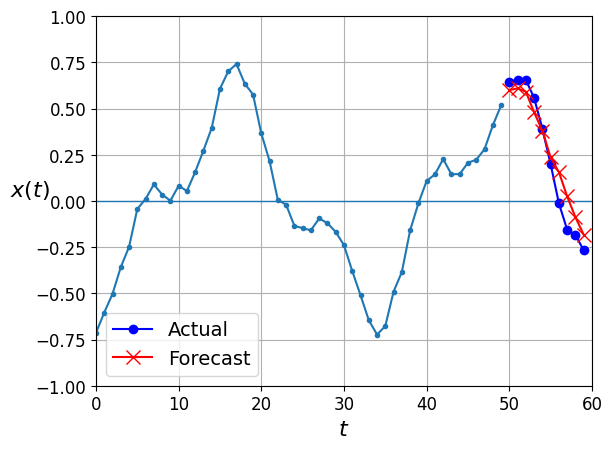

In [60]:
plot_multiple_forecasts(X_new, Y_new, Y_pred)
plt.show()

In [61]:
np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.Conv1D(filters=20, kernel_size=4, strides=2, padding="valid",
                        input_shape=[None, 1]),
    keras.layers.GRU(20, return_sequences=True),
    keras.layers.GRU(20, return_sequences=True),
    keras.layers.TimeDistributed(keras.layers.Dense(10))
])

model.compile(loss="mse", optimizer="adam", metrics=[last_time_step_mse])
history = model.fit(X_train, Y_train[:, 3::2], epochs=20,
                    validation_data=(X_valid, Y_valid[:, 3::2]))

Epoch 1/20
219/219 [==============================] - 16s 60ms/step - loss: 0.0687 - last_time_step_mse: 0.0610 - val_loss: 0.0469 - val_last_time_step_mse: 0.0390
Epoch 2/20
219/219 [==============================] - 12s 56ms/step - loss: 0.0392 - last_time_step_mse: 0.0318 - val_loss: 0.0339 - val_last_time_step_mse: 0.0254
Epoch 3/20
219/219 [==============================] - 11s 51ms/step - loss: 0.0311 - last_time_step_mse: 0.0226 - val_loss: 0.0287 - val_last_time_step_mse: 0.0194
Epoch 4/20
219/219 [==============================] - 12s 53ms/step - loss: 0.0269 - last_time_step_mse: 0.0172 - val_loss: 0.0256 - val_last_time_step_mse: 0.0160
Epoch 5/20
219/219 [==============================] - 11s 49ms/step - loss: 0.0246 - last_time_step_mse: 0.0142 - val_loss: 0.0246 - val_last_time_step_mse: 0.0155
Epoch 6/20
219/219 [==============================] - 14s 64ms/step - loss: 0.0232 - last_time_step_mse: 0.0125 - val_loss: 0.0228 - val_last_time_step_mse: 0.0119
Epoch 7/20
219/2

In [62]:
np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential()
model.add(keras.layers.InputLayer(input_shape=[None, 1]))
for rate in (1, 2, 4, 8) * 2:
    model.add(keras.layers.Conv1D(filters=20, kernel_size=2, padding="causal",
                                  activation="relu", dilation_rate=rate))
model.add(keras.layers.Conv1D(filters=10, kernel_size=1))
model.compile(loss="mse", optimizer="adam", metrics=[last_time_step_mse])
history = model.fit(X_train, Y_train, epochs=20,
                    validation_data=(X_valid, Y_valid))

Epoch 1/20
219/219 [==============================] - 4s 14ms/step - loss: 0.0646 - last_time_step_mse: 0.0526 - val_loss: 0.0352 - val_last_time_step_mse: 0.0219
Epoch 2/20
219/219 [==============================] - 3s 12ms/step - loss: 0.0325 - last_time_step_mse: 0.0199 - val_loss: 0.0297 - val_last_time_step_mse: 0.0167
Epoch 3/20
219/219 [==============================] - 3s 14ms/step - loss: 0.0288 - last_time_step_mse: 0.0161 - val_loss: 0.0278 - val_last_time_step_mse: 0.0151
Epoch 4/20
219/219 [==============================] - 3s 13ms/step - loss: 0.0272 - last_time_step_mse: 0.0146 - val_loss: 0.0261 - val_last_time_step_mse: 0.0133
Epoch 5/20
219/219 [==============================] - 3s 12ms/step - loss: 0.0257 - last_time_step_mse: 0.0134 - val_loss: 0.0251 - val_last_time_step_mse: 0.0126
Epoch 6/20
219/219 [==============================] - 1s 4ms/step - loss: 0.0246 - last_time_step_mse: 0.0124 - val_loss: 0.0239 - val_last_time_step_mse: 0.0112
Epoch 7/20
219/219 [===

In [63]:
class GatedActivationUnit(keras.layers.Layer):
    def __init__(self, activation="tanh", **kwargs):
        super().__init__(**kwargs)
        self.activation = keras.activations.get(activation)
    def call(self, inputs):
        n_filters = inputs.shape[-1] // 2
        linear_output = self.activation(inputs[..., :n_filters])
        gate = keras.activations.sigmoid(inputs[..., n_filters:])
        return self.activation(linear_output) * gate

In [64]:
def wavenet_residual_block(inputs, n_filters, dilation_rate):
    z = keras.layers.Conv1D(2 * n_filters, kernel_size=2, padding="causal",
                            dilation_rate=dilation_rate)(inputs)
    z = GatedActivationUnit()(z)
    z = keras.layers.Conv1D(n_filters, kernel_size=1)(z)
    return keras.layers.Add()([z, inputs]), z

In [65]:
keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

n_layers_per_block = 3 # 10 in the paper
n_blocks = 1 # 3 in the paper
n_filters = 32 # 128 in the paper
n_outputs = 10 # 256 in the paper

inputs = keras.layers.Input(shape=[None, 1])
z = keras.layers.Conv1D(n_filters, kernel_size=2, padding="causal")(inputs)
skip_to_last = []
for dilation_rate in [2**i for i in range(n_layers_per_block)] * n_blocks:
    z, skip = wavenet_residual_block(z, n_filters, dilation_rate)
    skip_to_last.append(skip)
z = keras.activations.relu(keras.layers.Add()(skip_to_last))
z = keras.layers.Conv1D(n_filters, kernel_size=1, activation="relu")(z)
Y_proba = keras.layers.Conv1D(n_outputs, kernel_size=1, activation="softmax")(z)

model = keras.models.Model(inputs=[inputs], outputs=[Y_proba])

In [66]:
model.compile(loss="mse", optimizer="adam", metrics=[last_time_step_mse])
history = model.fit(X_train, Y_train, epochs=2,
                    validation_data=(X_valid, Y_valid))

Epoch 1/2
219/219 [==============================] - 5s 18ms/step - loss: 0.1297 - last_time_step_mse: 0.1257 - val_loss: 0.1229 - val_last_time_step_mse: 0.1199
Epoch 2/2
219/219 [==============================] - 4s 17ms/step - loss: 0.1221 - last_time_step_mse: 0.1177 - val_loss: 0.1217 - val_last_time_step_mse: 0.1189


In [67]:
DOWNLOAD_ROOT = "http://download.tensorflow.org/data/"
FILENAME = "quickdraw_tutorial_dataset_v1.tar.gz"
filepath = keras.utils.get_file(FILENAME,
                                DOWNLOAD_ROOT + FILENAME,
                                cache_subdir="datasets/quickdraw",
                                extract=True)

1065301781/1065301781 [==============================] - 99s 0us/step
